<a href="https://colab.research.google.com/github/susihad/bioprocess-control-strategies/blob/main/penicillin_simulation_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Comparative Analysis of Bioprocess Control Strategies in Penicillin Production

The data used for this study is from www.industrialpenicillinsimulation.com. The data was generated using an advanced mathematical simulation of a 100,000 litre penicillin fermentation system referenced as IndPenSim.

Reference:

Goldrick S., Stefan, A., Lovett D., Montague G., Lennox B. (2015) The development of an industrial-scale fed-batch fermentation simulation Journal of Biotechnology, 193:70-82.

Goldrick S., Duran-Villalobos C., K. Jankauskas, Lovett D., Farid S. S, Lennox B., (2019) Modern day control challenges for industrial-scale fermentation processes. Computers and Chemical Engineering.

##Data Preparation

In [ ]:
import pandas as pd
from google.colab import drive
import zipfile
import os
import dask.dataframe as dd
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
import numpy as np
from scipy import stats
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Connect google.colab to the drive of the datafile
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract the zipfile
zip_path = '/content/drive/MyDrive/Bio Data/100_Batches_IndPenSim.zip'
extract_path = '/content/drive/MyDrive/Bio Data/100_Batches_IndPenSim'

# Extract only if folder doesn’t exist
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Files extracted.")
else:
    print("Files already extracted.")

#Check whats in the extracted folder
for file in os.listdir(extract_path):
    print(file)

Files already extracted.
Mendeley_data


In [ ]:
#Check further whats in the extracted folder
mendeley_path = os.path.join(extract_path, "Mendeley_data")
print("Files in Mendeley_data:")
for f in os.listdir(mendeley_path):
    print(" -", f)

Files in Mendeley_data:
 - 100_Batches_IndPenSim_Statistics.csv
 - 100_Batches_IndPenSim_V3.csv


In [ ]:
stats_file = '/content/drive/MyDrive/Bio Data/100_Batches_IndPenSim/Mendeley_data/100_Batches_IndPenSim_Statistics.csv'
df_stats = pd.read_csv(stats_file)

df_stats.info()
df_stats.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Batch ref                              100 non-null    int64  
 1   Penicllin_harvested_during_batch(kg)   100 non-null    float64
 2   Penicllin_harvested_end_of_batch (kg)  100 non-null    float64
 3   Penicllin_yield_total (kg)             100 non-null    float64
 4   Fault ref(0-NoFault 1-Fault)           100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0


In [ ]:
#large_file = '/content/drive/MyDrive/Bio Data/100_Batches_IndPenSim/Mendeley_data/100_Batches_IndPenSim_V3.csv'

# Load safely
#df_large = dd.read_csv(large_file, assume_missing=True)

# Count columns and rows
#num_cols = len(df_large.columns)
#num_rows = df_large.shape[0].compute()
#print(f"The dataset has {num_rows:,} rows and {num_cols} columns.")

In [ ]:
# only the column name is exported as csv file to understand the features in the dataset

output_path = '/content/drive/MyDrive/Bio Data/column_names.csv'
col_names = df_large.columns.compute() if hasattr(df_large.columns, "compute") else df_large.columns
pd.Series(col_names).to_csv(output_path, index=False, header=['column_name'])
print(f"Column names saved to Google Drive at:\n{output_path}")

In [ ]:
# Select the first 39 columns

df_39 = df_large.iloc[:, :39]
print(f"df_39 created with {len(df_39.columns)} columns and all {df_large.shape[0].compute():,} rows.")

In [ ]:
# save the file as scv to drive

output_path = '/content/drive/MyDrive/Bio Data/df_39.csv'
df_39.to_csv(output_path, single_file=True, index=False)
print(f"Saved df_39 to: {output_path}")

In [ ]:
# Import the df_39 file

file_path = '/content/drive/MyDrive/Bio Data/df_39.csv'
df_39 = pd.read_csv(file_path)
df_39.info()
df_39.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Data columns (total 39 columns):
 #   Column                                                              Non-Null Count   Dtype  
---  ------                                                              --------------   -----  
 0   Time (h)                                                            113935 non-null  float64
 1   Aeration rate(Fg:L/h)                                               113935 non-null  float64
 2   Agitator RPM(RPM:RPM)                                               113935 non-null  float64
 3   Sugar feed rate(Fs:L/h)                                             113935 non-null  float64
 4   Acid flow rate(Fa:L/h)                                              113935 non-null  float64
 5   Base flow rate(Fb:L/h)                                              113935 non-null  float64
 6   Heating/cooling water flow rate(Fc:L/h)                             113935 non-null  float64
 7   He

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Batch reference(Batch_ref:Batch ref),Batch ID,Fault flag
0,0.2,30.0,100.0,8.0,0.0000,30.118,9.8335,0.0001,0.0,0.6,...,0.0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
1,0.4,30.0,100.0,8.0,0.0000,51.221,18.1550,0.0001,0.0,0.6,...,0.0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
2,0.6,30.0,100.0,8.0,0.0000,54.302,9.5982,0.0001,0.0,0.6,...,0.0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
3,0.8,30.0,100.0,8.0,0.0000,37.816,4.3395,0.0001,0.0,0.6,...,0.0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
4,1.0,30.0,100.0,8.0,0.5181,18.908,1.1045,0.0001,0.0,0.6,...,0.0,4.083,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


##Data Analysis

### Productivity

In [ ]:
# Checking the duration of batches
batch_time_desc = (
    df_39.groupby('2-PAT control(PAT_ref:PAT ref)')['Time (h)']
    .max()
    .describe()
)
print(batch_time_desc)

count    100.000000
mean     227.870000
std       18.150691
min      167.000000
25%      227.500000
50%      230.000000
75%      230.000000
max      290.000000
Name: Time (h), dtype: float64


The 100 batches are controlled using different control strategies and different batch lengths representing a typical Biopharmaceutical manufacturing facility:

- Batches 1-30: Controlled by recipe driven approach
- Batches 31-60: Controlled by operators
- Batches 61-90: Controlled by an Advanced Process Control (APC) solution using the Raman spectroscopy
- Batches 91-100: Contain faults resulting in process deviations.

Batch reference of data is found under: 2-PAT control(PAT_ref:PAT ref)

In [ ]:
# Get max time (hour) per batch from df_39
batch_time = (
    df_39.groupby('2-PAT control(PAT_ref:PAT ref)')['Time (h)']
    .max()
    .reset_index()
    .rename(columns={'2-PAT control(PAT_ref:PAT ref)': 'Batch ref', 'Time (h)': 'Max_Time_h'})
)

# Merge with df_stats
df_yield = df_stats.merge(batch_time, on='Batch ref', how='left')

# Compute kg/hour for 3 columns
for col in [
    'Penicllin_harvested_during_batch(kg)',
    'Penicllin_harvested_end_of_batch (kg)',
    'Penicllin_yield_total (kg)'
]:
    df_yield[col + '_per_hour'] = df_yield[col] / df_yield['Max_Time_h']

# Add control strategy column
def get_control_strategy(batch):
    if 1 <= batch <= 30:
        return 'recipe'
    elif 31 <= batch <= 60:
        return 'operator'
    elif 61 <= batch <= 90:
        return 'APC'
    else:
        return 'faults'

df_yield['Control_strategy'] = df_yield['Batch ref'].apply(get_control_strategy)

# Drop unnecessary columns
cols_to_drop = [
    'Penicllin_harvested_during_batch(kg)',
    'Penicllin_harvested_end_of_batch (kg)',
    'Penicllin_yield_total (kg)',
    'Fault ref(0-NoFault 1-Fault)'
]
df_yield = df_yield.drop(columns=cols_to_drop, errors='ignore')

# Preview result
df_yield.info()
df_yield.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Batch ref                                       100 non-null    int64  
 1   Max_Time_h                                      100 non-null    float64
 2   Penicllin_harvested_during_batch(kg)_per_hour   100 non-null    float64
 3   Penicllin_harvested_end_of_batch (kg)_per_hour  100 non-null    float64
 4   Penicllin_yield_total (kg)_per_hour             100 non-null    float64
 5   Control_strategy                                100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


,Batch ref,Max_Time_h,Penicllin_harvested_during_batch(kg)_per_hour,Penicllin_harvested_end_of_batch (kg)_per_hour,Penicllin_yield_total (kg)_per_hour,Control_strategy
0,1,226.0,4718.584071,7610.619469,12329.203540,recipe
1,2,230.0,4286.565217,5826.521739,10113.043478,recipe
2,3,278.0,5093.884892,4529.496403,9623.381295,recipe
3,4,230.0,3546.521739,4656.521739,8203.043478,recipe
4,5,179.0,6304.469274,13600.000000,19904.469274,recipe


In [ ]:
# Eliminating outliers productivity (yield kg/h)
# Exclude outlier of the batches (explored using Tableau)
exclude_batches = [85, 67]
df_yield = df_yield[~df_yield['Batch ref'].isin(exclude_batches)]

In [ ]:
# Checking whether the strategis statistically give different productivity
f_stat, p_value = f_oneway(
    df_yield[df_yield['Control_strategy'] == 'recipe']['Penicllin_yield_total (kg)_per_hour'],
    df_yield[df_yield['Control_strategy'] == 'operator']['Penicllin_yield_total (kg)_per_hour'],
    df_yield[df_yield['Control_strategy'] == 'APC']['Penicllin_yield_total (kg)_per_hour']
)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Significant difference between control strategies!")
else:
    print("No significant difference")

F-statistic: 7.1618
P-value: 0.001335
Significant difference between control strategies!


In [ ]:
# Recipe vs Operator
t1, p1 = ttest_ind(
    df_yield[df_yield['Control_strategy'] == 'recipe']['Penicllin_yield_total (kg)_per_hour'],
    df_yield[df_yield['Control_strategy'] == 'operator']['Penicllin_yield_total (kg)_per_hour']
)
print(f"Recipe vs Operator: t={t1:.4f}, p={p1:.6f}")

# Recipe vs APC
t2, p2 = ttest_ind(
    df_yield[df_yield['Control_strategy'] == 'recipe']['Penicllin_yield_total (kg)_per_hour'],
    df_yield[df_yield['Control_strategy'] == 'APC']['Penicllin_yield_total (kg)_per_hour']
)
print(f"Recipe vs APC: t={t2:.4f}, p={p2:.6f}")

# Operator vs APC
t3, p3 = ttest_ind(
    df_yield[df_yield['Control_strategy'] == 'operator']['Penicllin_yield_total (kg)_per_hour'],
    df_yield[df_yield['Control_strategy'] == 'APC']['Penicllin_yield_total (kg)_per_hour']
)
print(f"Operator vs APC: t={t3:.4f}, p={p3:.6f}")

Recipe vs Operator: t=0.5328, p=0.596182
Recipe vs APC: t=-3.0298, p=0.003699
Operator vs APC: t=-4.3470, p=0.000059


Findings:

1. Recipe vs Operator: NOT significantly different. p = 0.5328 (way above 0.05) These two strategies perform about the same.
2. Recipe vs APC: significant. p = 0.003699 (p < 0.005) * t = -3.03 (negative means APC is better) APC-Raman significantly outperforms Recipe-Driven.
3. Operator vs APC: EXTREMELY significant. p = 0.000059 (p < 0.0001) *** t = -4.35 (negative means APC is better) APC-Raman significantly outperforms Operator-Controlled.

In [ ]:
# Calculate means for each strategy
recipe_mean = df_yield[df_yield['Control_strategy'] == 'recipe']['Penicllin_yield_total (kg)_per_hour'].mean()
operator_mean = df_yield[df_yield['Control_strategy'] == 'operator']['Penicllin_yield_total (kg)_per_hour'].mean()
apc_mean = df_yield[df_yield['Control_strategy'] == 'APC']['Penicllin_yield_total (kg)_per_hour'].mean()

print("Mean Productivity (kg/h):")
print(f"  Recipe-Driven:        {recipe_mean:.4f}")
print(f"  Operator-Controlled:  {operator_mean:.4f}")
print(f"  APC-Raman:           {apc_mean:.4f}")
print()

# Calculate absolute improvements
print("Absolute Improvement (kg/h):")
print(f"  APC vs Recipe:    +{apc_mean - recipe_mean:.4f}")
print(f"  APC vs Operator:  +{apc_mean - operator_mean:.4f}")
print()

# Calculate percentage improvements
recipe_improvement = ((apc_mean - recipe_mean) / recipe_mean) * 100
operator_improvement = ((apc_mean - operator_mean) / operator_mean) * 100

print("Percentage Improvement:")
print(f"  APC vs Recipe:    +{recipe_improvement:.2f}%")
print(f"  APC vs Operator:  +{operator_improvement:.2f}%")
print()

Mean Productivity (kg/h):
  Recipe-Driven:        12916.6189
  Operator-Controlled:  12431.0181
  APC-Raman:           15247.9735

Absolute Improvement (kg/h):
  APC vs Recipe:    +2331.3546
  APC vs Operator:  +2816.9554

Percentage Improvement:
  APC vs Recipe:    +18.05%
  APC vs Operator:  +22.66%



APC-Raman Performance: +18.05% improvement over Recipe-Driven
+22.66% improvement over Operator-Controlled

In [ ]:
# Effect size (Cohen's d) for ALL pairwise comparisons

recipe_data = df_yield[df_yield['Control_strategy'] == 'recipe']['Penicllin_yield_total (kg)_per_hour']
operator_data = df_yield[df_yield['Control_strategy'] == 'operator']['Penicllin_yield_total (kg)_per_hour']
apc_data = df_yield[df_yield['Control_strategy'] == 'APC']['Penicllin_yield_total (kg)_per_hour']

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1 + n2 - 2))

    # Cohen's d
    d = (mean1 - mean2) / pooled_std
    return d

print("Effect Size (Cohen's d):")

# Recipe vs Operator
d1 = cohens_d(recipe_data, operator_data)
print(f"Recipe vs Operator:     {d1:.3f}")

# Recipe vs APC
d2 = cohens_d(recipe_data, apc_data)
print(f"Recipe vs APC:          {d2:.3f}")

# Operator vs APC
d3 = cohens_d(operator_data, apc_data)
print(f"Operator vs APC:        {d3:.3f}")

Effect Size (Cohen's d):
Recipe vs Operator:     0.138
Recipe vs APC:          -0.796
Operator vs APC:        -1.142


Interpretation Guide:
  
  |d| < 0.2: Small effect

  |d| < 0.5: Medium effect
  
  |d| < 0.8: Large effect
  
  |d| ≥ 0.8: Very large effect

Cohen's d Results:
1. Recipe vs Operator: d = 0.138 (Small effect). Practically no difference
Confirms the t-test (p = 0.538). Conclusion: Manual operator control doesn't really help without data feedback

2. Recipe vs APC: d = -0.798 (Large effect). Negative = APC is better
18.05% productivity improvement. Strong practical AND statistical significance

3. Operator vs APC: d = -1.142 (EXTREMELY large effect). Even bigger effect than Recipe vs APC! 22.66% productivity improvement. This is the most dramatic difference

###Economic Impact

In [ ]:
# Economic Impact Calculation

# Batch parameters
batch_duration = 230               # hours
penicillin_price = 100            # USD per kg

# Calculate batches per year
hours_per_year = 365 * 24         # 8,760 hours
total_cycle_time = batch_duration + 30  # 260 hours per batch cycle (including prep/cleaning)
batches_per_year = hours_per_year / total_cycle_time

print("ECONOMIC IMPACT OF APC-RAMAN IMPLEMENTATION")

print(f"\nBatch Parameters:")
print(f"  Batch duration: {batch_duration} hours")
print(f"  Total cycle time (including prep/cleaning): {total_cycle_time} hours")
print(f"  Batches per year: {batches_per_year:.1f} batches")

# APC vs RECIPE

improvement_vs_recipe = apc_mean - recipe_mean

print("APC-RAMAN vs RECIPE-DRIVEN")

print(f"\nProductivity:")
print(f"  Recipe-Driven: {recipe_mean:,.2f} kg/h")
print(f"  APC-Raman: {apc_mean:,.2f} kg/h")
print(f"  Improvement: {improvement_vs_recipe:,.2f} kg/h ({(improvement_vs_recipe/recipe_mean*100):.2f}%)")

# Calculate extra production
extra_per_batch_recipe = improvement_vs_recipe * batch_duration
annual_extra_recipe = extra_per_batch_recipe * batches_per_year
annual_revenue_recipe = annual_extra_recipe * penicillin_price

# Calculate baseline revenue
baseline_production_recipe = recipe_mean * batch_duration * batches_per_year
baseline_revenue_recipe = baseline_production_recipe * penicillin_price
revenue_increase_pct_recipe = (annual_revenue_recipe / baseline_revenue_recipe) * 100

print(f"\nProduction Gain:")
print(f"  Extra per batch: {extra_per_batch_recipe:,.2f} kg")
print(f"  Extra per year: {annual_extra_recipe:,.2f} kg/year")

print(f"\nFinancial Impact:")
print(f"  Baseline revenue (Recipe): ${baseline_revenue_recipe:,.2f} USD/year")
print(f"  Additional revenue: ${annual_revenue_recipe:,.2f} USD/year ({revenue_increase_pct_recipe:.2f}%)")

# APC vs OPERATOR

improvement_vs_operator = apc_mean - operator_mean

print("APC-RAMAN vs OPERATOR-CONTROLLED")

print(f"\nProductivity:")
print(f"  Operator-Controlled: {operator_mean:,.2f} kg/h")
print(f"  APC-Raman: {apc_mean:,.2f} kg/h")
print(f"  Improvement: {improvement_vs_operator:,.2f} kg/h ({(improvement_vs_operator/operator_mean*100):.2f}%)")

# Calculate extra production
extra_per_batch_operator = improvement_vs_operator * batch_duration
annual_extra_operator = extra_per_batch_operator * batches_per_year
annual_revenue_operator = annual_extra_operator * penicillin_price

# Calculate baseline revenue
baseline_production_operator = operator_mean * batch_duration * batches_per_year
baseline_revenue_operator = baseline_production_operator * penicillin_price
revenue_increase_pct_operator = (annual_revenue_operator / baseline_revenue_operator) * 100

print(f"\nProduction Gain:")
print(f"  Extra per batch: {extra_per_batch_operator:,.2f} kg")
print(f"  Extra per year: {annual_extra_operator:,.2f} kg/year")

print(f"\nFinancial Impact:")
print(f"  Baseline revenue (Operator): ${baseline_revenue_operator:,.2f} USD/year")
print(f"  Additional revenue: ${annual_revenue_operator:,.2f} USD/year ({revenue_increase_pct_operator:.2f}%)")

# SUMMARY

print("SUMMARY")
print(f"\nBy implementing APC-Raman instead of:")
print(f"\n  Recipe-Driven:")
print(f"    • {improvement_vs_recipe:+,.2f} kg/h improvement ({(improvement_vs_recipe/recipe_mean*100):.2f}%)")
print(f"    • {extra_per_batch_recipe:,.0f} kg extra per batch")
print(f"    • ${annual_revenue_recipe:,.0f} USD additional revenue/year ({revenue_increase_pct_recipe:.2f}%)")

print(f"\n  Operator-Controlled:")
print(f"    • {improvement_vs_operator:+,.2f} kg/h improvement ({(improvement_vs_operator/operator_mean*100):.2f}%)")
print(f"    • {extra_per_batch_operator:,.0f} kg extra per batch")
print(f"    • ${annual_revenue_operator:,.0f} USD additional revenue/year ({revenue_increase_pct_operator:.2f}%)")

ECONOMIC IMPACT OF APC-RAMAN IMPLEMENTATION

Batch Parameters:
  Batch duration: 230 hours
  Total cycle time (including prep/cleaning): 260 hours
  Batches per year: 33.7 batches
APC-RAMAN vs RECIPE-DRIVEN

Productivity:
  Recipe-Driven: 12,916.62 kg/h
  APC-Raman: 15,247.97 kg/h
  Improvement: 2,331.35 kg/h (18.05%)

Production Gain:
  Extra per batch: 536,211.56 kg
  Extra per year: 18,066,204.74 kg/year

Financial Impact:
  Baseline revenue (Recipe): $10,009,386,095.13 USD/year
  Additional revenue: $1,806,620,473.66 USD/year (18.05%)
APC-RAMAN vs OPERATOR-CONTROLLED

Productivity:
  Operator-Controlled: 12,431.02 kg/h
  APC-Raman: 15,247.97 kg/h
  Improvement: 2,816.96 kg/h (22.66%)

Production Gain:
  Extra per batch: 647,899.74 kg
  Extra per year: 21,829,237.51 kg/year

Financial Impact:
  Baseline revenue (Operator): $9,633,082,817.48 USD/year
  Additional revenue: $2,182,923,751.32 USD/year (22.66%)
SUMMARY

By implementing APC-Raman instead of:

  Recipe-Driven:
    • +2,331

###Control Quality

In [ ]:
# Classify and clean data

def get_control_strategy(batch_ref):
    """Map batch number to control strategy"""
    if 1 <= batch_ref <= 30:
        return 'recipe'
    elif 31 <= batch_ref <= 60:
        return 'operator'
    elif 61 <= batch_ref <= 90:
        return 'APC'
    else:
        return 'faults'

# Add control strategy and exclude outlier batches
batches_to_exclude = [85, 67]
df_39_clean = df_39[~df_39['2-PAT control(PAT_ref:PAT ref)'].isin(batches_to_exclude)].copy()
df_39_clean['control_strategy'] = df_39_clean['2-PAT control(PAT_ref:PAT ref)'].apply(get_control_strategy)


In [ ]:
# PAA CONTROL QUALITY ANALYSIS
# Root Cause Investigation: Why APC-Raman Performs Better

print("ROOT CAUSE INVESTIGATION: PAA CONTROL QUALITY")

# Extract PAA Data
# PAA is measured offline - get the column name
paa_column = 'PAA concentration offline(PAA_offline:PAA (g L^{-1}))'

# Check if column exists
if paa_column in df_39_clean.columns:
    print(f"Total records: {df_39_clean[paa_column].notna().sum():,}")
else:
    print("PAA column not found!")

# Calculate PAA Stability (CV%) per Batch

paa_stability = []

for batch_id in df_39_clean['2-PAT control(PAT_ref:PAT ref)'].unique():
    batch_data = df_39_clean[df_39_clean['2-PAT control(PAT_ref:PAT ref)'] == batch_id]
    strategy = batch_data['control_strategy'].iloc[0]

    # Get PAA measurements for this batch
    paa_values = batch_data[paa_column].dropna()

    if len(paa_values) > 1:  # Need at least 2 measurements
        paa_mean = paa_values.mean()
        paa_std = paa_values.std()
        paa_cv = (paa_std / paa_mean) * 100 if paa_mean != 0 else np.nan

        paa_stability.append({
            'Batch_ID': batch_id,
            'control_strategy': strategy,
            'PAA_mean': paa_mean,
            'PAA_std': paa_std,
            'PAA_CV%': paa_cv,
            'N_measurements': len(paa_values)
        })

df_paa_stability = pd.DataFrame(paa_stability)

# Remove faulty batches
df_paa_stability = df_paa_stability[df_paa_stability['control_strategy'] != 'faults']

print(f"Calculated PAA stability for {len(df_paa_stability)} batches")
print(f"\nSample data:")
print(df_paa_stability.head())

# Compare PAA Stability Across Strategies

print("\n")
print("PAA STABILITY COMPARISON")

for strategy in ['recipe', 'operator', 'APC']:
    strategy_data = df_paa_stability[df_paa_stability['control_strategy'] == strategy]

    if len(strategy_data) > 0:
        mean_cv = strategy_data['PAA_CV%'].mean()
        std_cv = strategy_data['PAA_CV%'].std()
        n_batches = len(strategy_data)

        print(f"\n{strategy}:")
        print(f"  Mean CV%: {mean_cv:.2f}%")
        print(f"  Std CV%: {std_cv:.2f}%")
        print(f"  N batches: {n_batches}")

# Calculate improvements
recipe_cv = df_paa_stability[df_paa_stability['control_strategy'] == 'recipe']['PAA_CV%'].mean()
operator_cv = df_paa_stability[df_paa_stability['control_strategy'] == 'operator']['PAA_CV%'].mean()
apc_cv = df_paa_stability[df_paa_stability['control_strategy'] == 'APC']['PAA_CV%'].mean()

improvement_vs_recipe = ((recipe_cv - apc_cv) / recipe_cv) * 100
improvement_vs_operator = ((operator_cv - apc_cv) / operator_cv) * 100

print(f"\n")
print("PAA STABILITY IMPROVEMENT:")
print(f"  Recipe CV:   {recipe_cv:.2f}% → APC CV: {apc_cv:.2f}%")
print(f"  APC is {improvement_vs_recipe:.1f}% more stable than Recipe")
print(f"\n  Operator CV: {operator_cv:.2f}% → APC CV: {apc_cv:.2f}%")
print(f"  APC is {improvement_vs_operator:.1f}% more stable than Operator")

# Statistical Significance Test

print("\n")
print("STATISTICAL SIGNIFICANCE")

recipe_data = df_paa_stability[df_paa_stability['control_strategy'] == 'recipe']['PAA_CV%'].dropna()
operator_data = df_paa_stability[df_paa_stability['control_strategy'] == 'operator']['PAA_CV%'].dropna()
apc_data = df_paa_stability[df_paa_stability['control_strategy'] == 'APC']['PAA_CV%'].dropna()

# ANOVA
f_stat, p_anova = stats.f_oneway(recipe_data, operator_data, apc_data)
print(f"\nANOVA Test:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_anova:.6f}")

if p_anova < 0.05:
    print(f"  Significant difference exists (p < 0.05)")

    # Pairwise t-tests
    print(f"\nPairwise Comparisons:")

    t1, p1 = stats.ttest_ind(recipe_data, apc_data)
    print(f"  Recipe vs APC: t={t1:.3f}, p={p1:.6f} {'***' if p1 < 0.001 else '**' if p1 < 0.01 else '*' if p1 < 0.05 else 'ns'}")

    t2, p2 = stats.ttest_ind(operator_data, apc_data)
    print(f"  Operator vs APC: t={t2:.3f}, p={p2:.6f} {'***' if p2 < 0.001 else '**' if p2 < 0.01 else '*' if p2 < 0.05 else 'ns'}")

    t3, p3 = stats.ttest_ind(recipe_data, operator_data)
    print(f"  Recipe vs Operator: t={t3:.3f}, p={p3:.6f} {'***' if p3 < 0.001 else '**' if p3 < 0.01 else '*' if p3 < 0.05 else 'ns'}")
else:
    print(f"  No significant difference (p ≥ 0.05)")

ROOT CAUSE INVESTIGATION: PAA CONTROL QUALITY
Total records: 2,029
Calculated PAA stability for 88 batches

Sample data:
   Batch_ID control_strategy     PAA_mean      PAA_std    PAA_CV%  \
0       1.0           recipe  1499.368000   281.986645  18.807034   
1       2.0           recipe  1045.754762   321.043046  30.699649   
2       3.0           recipe  2167.472800  1265.489213  58.385471   
3       4.0           recipe  2552.328095  1609.497925  63.059993   
4       5.0           recipe  1295.253750   286.525290  22.121170   

   N_measurements  
0              20  
1              21  
2              25  
3              21  
4              16  


PAA STABILITY COMPARISON

recipe:
  Mean CV%: 41.81%
  Std CV%: 18.34%
  N batches: 30

operator:
  Mean CV%: 54.91%
  Std CV%: 21.35%
  N batches: 30

APC:
  Mean CV%: 6.90%
  Std CV%: 1.13%
  N batches: 28


PAA STABILITY IMPROVEMENT:
  Recipe CV:   41.81% → APC CV: 6.90%
  APC is 83.5% more stable than Recipe

  Operator CV: 54.91% → APC

PAA Conc. stability improvement:
  APC to recipe is 83.5%
  APC to operator is  87.4%

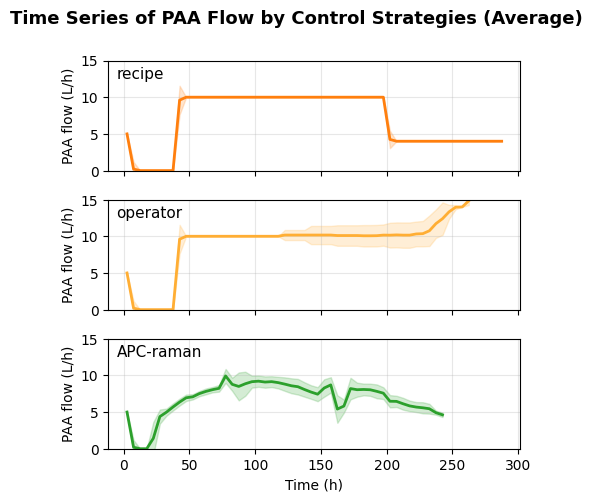

In [ ]:
# Time Series Visualization: PAA Flow by Control Strategies (Averaged)

# Get unique time points (assuming all batches have similar time range)
# We'll create time bins and average across batches

# Define common time grid
max_time = df_39_clean['Time (h)'].max()
time_bins = np.arange(0, max_time + 5, 5)  # 5-hour bins

# Function to calculate average profile
def get_average_profile(df, strategy, time_bins):
    strategy_data = df[df['control_strategy'] == strategy]

    # Group by time bins and calculate mean
    binned_data = []
    for i in range(len(time_bins) - 1):
        time_mask = (strategy_data['Time (h)'] >= time_bins[i]) & \
                   (strategy_data['Time (h)'] < time_bins[i+1])
        bin_data = strategy_data[time_mask]['PAA flow(Fpaa:PAA flow (L/h))']

        if len(bin_data) > 0:
            binned_data.append({
                'time': (time_bins[i] + time_bins[i+1]) / 2,
                'mean': bin_data.mean(),
                'std': bin_data.std()
            })

    return pd.DataFrame(binned_data)

# Calculate averages for each strategy
recipe_avg = get_average_profile(df_39_clean, 'recipe', time_bins)
operator_avg = get_average_profile(df_39_clean, 'operator', time_bins)
apc_avg = get_average_profile(df_39_clean, 'APC', time_bins)

# Create the plot
fig, axes = plt.subplots(3, 1, figsize=(5, 5), sharex=True)

# Recipe
axes[0].plot(recipe_avg['time'], recipe_avg['mean'],
             color='#ff7f0e', linewidth=2)
axes[0].fill_between(recipe_avg['time'],
                     recipe_avg['mean'] - recipe_avg['std'],
                     recipe_avg['mean'] + recipe_avg['std'],
                     color='#ff7f0e', alpha=0.2)
axes[0].text(0.02, 0.95, 'recipe', transform=axes[0].transAxes,
            fontsize=11, verticalalignment='top')
axes[0].set_ylabel('PAA flow (L/h)', fontsize=10)
axes[0].set_ylim(0, 15)
axes[0].grid(True, alpha=0.3)

# Operator
axes[1].plot(operator_avg['time'], operator_avg['mean'],
             color='#ffae34', linewidth=2)
axes[1].fill_between(operator_avg['time'],
                     operator_avg['mean'] - operator_avg['std'],
                     operator_avg['mean'] + operator_avg['std'],
                     color='#ffae34', alpha=0.2)
axes[1].text(0.02, 0.95, 'operator', transform=axes[1].transAxes,
            fontsize=11, verticalalignment='top')
axes[1].set_ylabel('PAA flow (L/h)', fontsize=10)
axes[1].set_ylim(0, 15)
axes[1].grid(True, alpha=0.3)

# APC
axes[2].plot(apc_avg['time'], apc_avg['mean'],
             color='#2ca02c', linewidth=2)
axes[2].fill_between(apc_avg['time'],
                     apc_avg['mean'] - apc_avg['std'],
                     apc_avg['mean'] + apc_avg['std'],
                     color='#2ca02c', alpha=0.2)
axes[2].text(0.02, 0.95, 'APC-raman', transform=axes[2].transAxes,
            fontsize=11, verticalalignment='top')
axes[2].set_ylabel('PAA flow (L/h)', fontsize=10)
axes[2].set_xlabel('Time (h)', fontsize=10)
axes[2].set_ylim(0, 15)
axes[2].grid(True, alpha=0.3)

# Overall title
fig.suptitle('Time Series of PAA Flow by Control Strategies (Average)',
             fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('paa_flow_timeseries_average.png', dpi=300, bbox_inches='tight')
plt.show()

Recipe and Operator-Controlled strategies employ rigid, stepwise PAA feeding schedules (0-5-10 L/h), resulting in alternating periods of substrate starvation and excess. This control approach causes PAA concentration to fluctuate wildly (CV = 42-55%).

In contrast, APC-Raman continuously modulates PAA flow based on real-time spectroscopic feedback, maintaining smooth, consistent paa concentration. This results in 83-87% better PAA concentration stability (CV = 6.9%).


=========================END=========================